# 04 Motion Detection Score

Moving average, variance, thresholds, and motion/no-motion state from synthetic CSI amplitude.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(7)
n_samples = 500
n_subcarriers = 56
time_s = np.linspace(0, 20, n_samples)

baseline = 0.25 + 0.01 * rng.normal(size=(n_samples, n_subcarriers))
motion_window = (time_s > 7) & (time_s < 13)
pattern = np.sin(np.linspace(0, 4 * np.pi, n_subcarriers))
synthetic_amplitude = baseline.copy()
synthetic_amplitude[motion_window] += 0.045 * pattern + 0.025 * rng.normal(size=(motion_window.sum(), n_subcarriers))

reference = synthetic_amplitude[time_s <= 3].mean(axis=0)
raw_score = np.linalg.norm(synthetic_amplitude - reference, axis=1)

In [2]:
def moving_average(values, window):
    kernel = np.ones(window) / window
    return np.convolve(values, kernel, mode="same")

score_ma = moving_average(raw_score, window=15)
quiet = time_s <= 3
threshold = score_ma[quiet].mean() + 4.0 * score_ma[quiet].std(ddof=1)
motion_detected = score_ma > threshold

state = np.where(motion_detected, "motion", "no_motion")
np.unique(state, return_counts=True)

(array(['motion', 'no_motion'], dtype='<U9'), array([162, 338]))

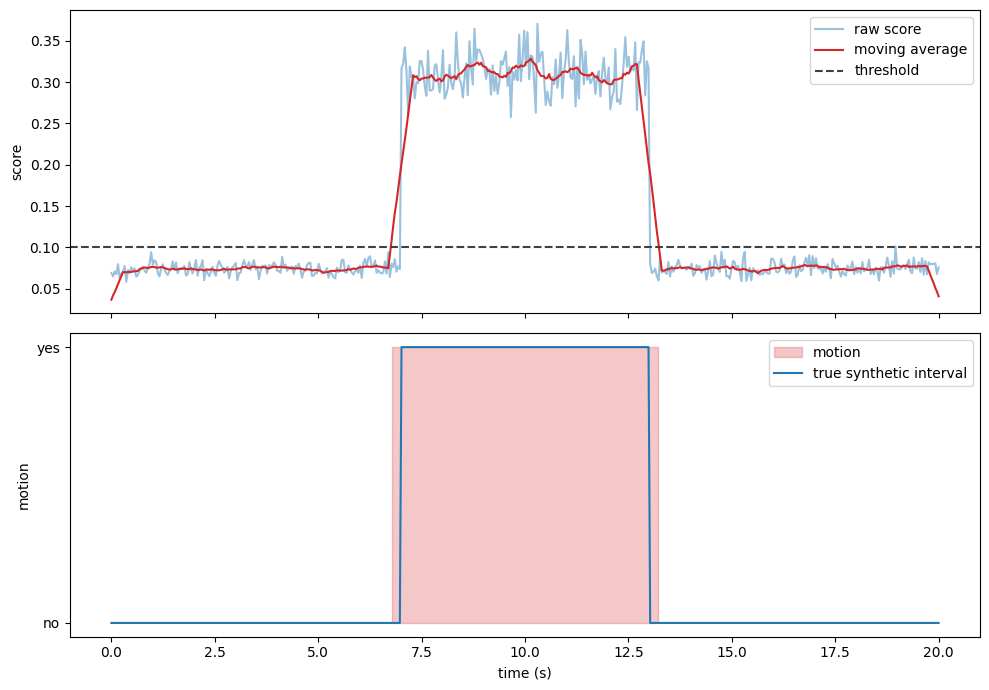

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
axes[0].plot(time_s, raw_score, alpha=0.45, label="raw score")
axes[0].plot(time_s, score_ma, color="tab:red", label="moving average")
axes[0].axhline(threshold, color="0.25", linestyle="--", label="threshold")
axes[0].set_ylabel("score")
axes[0].legend()

axes[1].fill_between(time_s, 0, 1, where=motion_detected, color="tab:red", alpha=0.25, label="motion")
axes[1].plot(time_s, motion_window.astype(float), color="tab:blue", label="true synthetic interval")
axes[1].set_yticks([0, 1])
axes[1].set_yticklabels(["no", "yes"])
axes[1].set_xlabel("time (s)")
axes[1].set_ylabel("motion")
axes[1].legend()

fig.tight_layout()
plt.show()